In [2]:
import os
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_recall_fscore_support,
    roc_auc_score,
    f1_score,
    matthews_corrcoef
)

In [3]:
# =========================
# 1) Paths (edit these)
# =========================
TFIDF_CSV = "/content/HDFS_tfidf_full.csv"
LABEL_CSV = "/content/anomaly_label.csv"   # <-- change if your label file has a different name/path

assert os.path.exists(TFIDF_CSV), f"Missing TFIDF file: {TFIDF_CSV}"
assert os.path.exists(LABEL_CSV), f"Missing LABEL file: {LABEL_CSV}"

In [4]:
# =========================
# 2) Load CSVs
# =========================
tfidf_df = pd.read_csv(TFIDF_CSV)
lab_df   = pd.read_csv(LABEL_CSV)

tfidf_df.columns = [c.strip() for c in tfidf_df.columns]
lab_df.columns   = [c.strip() for c in lab_df.columns]

print("TFIDF:", tfidf_df.shape)
print("LABEL:", lab_df.shape)
print("LABEL columns:", lab_df.columns.tolist())

TFIDF: (575061, 49)
LABEL: (575061, 2)
LABEL columns: ['BlockId', 'Label']


In [5]:
# =========================
# 3) Auto-detect join + label columns (like your notebook)
# =========================
ID_CANDIDATES = ["blockid","block_id","block","blk_id","BlockId","BlockID","id","Id"]
LABEL_CANDIDATES = ["label","labels","anomaly","is_anomaly","y","target","class"]

def detect_col(df, candidates):
    lower_map = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    return None

JOIN_COL  = detect_col(lab_df, ID_CANDIDATES)
LABEL_COL = detect_col(lab_df, LABEL_CANDIDATES)

if JOIN_COL is None:
    raise ValueError(f"Could not find BlockId-like column in label CSV. Columns: {lab_df.columns.tolist()}")
if LABEL_COL is None:
    raise ValueError(f"Could not find label column in label CSV. Columns: {lab_df.columns.tolist()}")

# If your TFIDF file has a different ID column name, we also detect it:
TFIDF_JOIN_COL = detect_col(tfidf_df, ID_CANDIDATES)
if TFIDF_JOIN_COL is None:
    raise ValueError(f"Could not find BlockId-like column in TFIDF CSV. Columns: {tfidf_df.columns.tolist()}")

print("JOIN_COL (labels):", JOIN_COL)
print("JOIN_COL (tfidf):", TFIDF_JOIN_COL)
print("LABEL_COL:", LABEL_COL)

JOIN_COL (labels): BlockId
JOIN_COL (tfidf): BlockId
LABEL_COL: Label


In [6]:
# =========================
# 4) Merge labels into TFIDF (labels only for evaluation)
# =========================
tfidf_m = tfidf_df.merge(
    lab_df[[JOIN_COL, LABEL_COL]].drop_duplicates(subset=[JOIN_COL]),
    left_on=TFIDF_JOIN_COL,
    right_on=JOIN_COL,
    how="inner"
)

print("Merged:", tfidf_m.shape)

Merged: (575061, 50)


In [7]:
# =========================
# 5) Build X / y
# =========================
def make_xy(df: pd.DataFrame, id_col_tfidf: str, id_col_label: str, label_col: str):
    y_raw = df[label_col]
    if pd.api.types.is_numeric_dtype(y_raw):
        y = (y_raw.astype(float) > 0).astype(int).values
    else:
        y_str = y_raw.astype(str).str.lower()
        y = y_str.isin(["1","true","anomaly","yes","y","abnormal"]).astype(int).values

    # Drop both id columns + label
    drop_cols = list({id_col_tfidf, id_col_label, label_col})
    X = df.drop(columns=drop_cols, errors="ignore")

    # ensure numeric
    for c in X.columns:
        if not pd.api.types.is_numeric_dtype(X[c]):
            X[c] = pd.to_numeric(X[c], errors="coerce")
    X = X.fillna(0.0)

    return X, y

X_df, y = make_xy(tfidf_m, TFIDF_JOIN_COL, JOIN_COL, LABEL_COL)
print("X:", X_df.shape, "y mean(anomaly rate):", y.mean())


X: (575061, 48) y mean(anomaly rate): 0.029280371995318757


In [8]:
# =========================
# 6) Evaluation helper
# =========================
def eval_predictions(y_true, y_pred, anomaly_scores=None, title=""):
    cm = confusion_matrix(y_true, y_pred)
    pr, rc, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    mcc = matthews_corrcoef(y_true, y_pred)

    print("\n" + "="*90)
    print(title)
    print("Confusion matrix [[TN FP],[FN TP]]:\n", cm)
    print(f"Precision: {pr:.4f} | Recall: {rc:.4f} | F1: {f1:.4f} | MCC: {mcc:.4f}")
    if anomaly_scores is not None:
        try:
            auc = roc_auc_score(y_true, anomaly_scores)
            print(f"ROC-AUC (score-based): {auc:.4f}")
        except Exception as e:
            print("ROC-AUC not computed:", e)

    print("\nClassification report:\n", classification_report(y_true, y_pred, digits=4, zero_division=0))


In [9]:
# =========================
# 7) K-Means -> Isolation Forest (per-cluster)
# =========================
# Scale first (important for KMeans + distance-based clustering)
scaler = StandardScaler(with_mean=True, with_std=True)
X_scaled = scaler.fit_transform(X_df.values.astype(np.float32))

# KMeans clustering (k=2)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Determine which cluster is larger (usually "more normal")
cluster_sizes = pd.Series(clusters).value_counts().sort_index()
large_cluster = int(cluster_sizes.idxmax())
small_cluster = 1 - large_cluster

print("Cluster sizes:", dict(cluster_sizes))
print("Large cluster:", large_cluster, "| Small cluster:", small_cluster)

# Fit iForest INSIDE EACH cluster (matches your text: "apply iForest separately to each cluster")
# contamination can be estimated from true anomaly rate (bounded) just for fair thresholding
# Fixed contamination (pure unsupervised setting)
contam = 0.01   # 1% anomalies assumption
print("Using FIXED contamination:", contam)

scores = np.zeros(len(y), dtype=np.float32)

for c in [0, 1]:
    idx = np.where(clusters == c)[0]
    X_c = X_scaled[idx]

    model = IsolationForest(
        n_estimators=300,
        contamination=contam,
        max_samples="auto",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_c)
    score_c = -model.decision_function(X_c)
    scores[idx] = score_c.astype(np.float32)

Cluster sizes: {0: np.int64(574998), 1: np.int64(63)}
Large cluster: 0 | Small cluster: 1
Using FIXED contamination: 0.01


In [10]:
# =========================
# 8) Convert scores -> binary predictions
#    Use contamination to set a global threshold (top contam fraction are anomalies)
# =========================
threshold = np.quantile(scores, 1.0 - contam)
y_pred = (scores >= threshold).astype(int)

eval_predictions(
    y_true=y,
    y_pred=y_pred,
    anomaly_scores=scores,
    title="KMeans(k=2) -> IsolationForest(per-cluster) | Global threshold by contamination"
)



KMeans(k=2) -> IsolationForest(per-cluster) | Global threshold by contamination
Confusion matrix [[TN FP],[FN TP]]:
 [[556546   1677]
 [ 10884   5954]]
Precision: 0.7802 | Recall: 0.3536 | F1: 0.4867 | MCC: 0.5166
ROC-AUC (score-based): 0.9875

Classification report:
               precision    recall  f1-score   support

           0     0.9808    0.9970    0.9888    558223
           1     0.7802    0.3536    0.4867     16838

    accuracy                         0.9782    575061
   macro avg     0.8805    0.6753    0.7377    575061
weighted avg     0.9749    0.9782    0.9741    575061



In [11]:
# =========================
# 9) Optional: threshold tuning for best F1 (like you did in your notebook)
# =========================
best_f1, best_t = -1, None
for t in np.percentile(scores, np.linspace(90, 99.9, 60)):
    yp = (scores >= t).astype(int)
    f1v = f1_score(y, yp, zero_division=0)
    if f1v > best_f1:
        best_f1, best_t = f1v, t

print("\nBest threshold (F1-tuned):", best_t)
print("Best F1:", best_f1)

y_pred_best = (scores >= best_t).astype(int)
eval_predictions(
    y_true=y,
    y_pred=y_pred_best,
    anomaly_scores=scores,
    title="KMeans(k=2) -> IsolationForest(per-cluster) | Threshold tuned for best F1"
)


Best threshold (F1-tuned): -0.011473570019006729
Best F1: 0.6778829053140784

KMeans(k=2) -> IsolationForest(per-cluster) | Threshold tuned for best F1
Confusion matrix [[TN FP],[FN TP]]:
 [[556476   1747]
 [  7309   9529]]
Precision: 0.8451 | Recall: 0.5659 | F1: 0.6779 | MCC: 0.6843
ROC-AUC (score-based): 0.9875

Classification report:
               precision    recall  f1-score   support

           0     0.9870    0.9969    0.9919    558223
           1     0.8451    0.5659    0.6779     16838

    accuracy                         0.9843    575061
   macro avg     0.9161    0.7814    0.8349    575061
weighted avg     0.9829    0.9843    0.9827    575061



In [12]:
block_ids = tfidf_m[TFIDF_JOIN_COL]
out = pd.DataFrame({
    "BlockId": block_ids.astype(str),
    "y_true": y.astype(int),
    "score_kmeans_iforest": scores.astype(float),
    "pred_kmeans_iforest": y_pred.astype(int)
})
out.to_csv("/content/kmeans_iforest_results.csv", index=False)

# Task
Create a visualization that displays the distribution of anomaly scores for correctly and incorrectly classified points from the F1-tuned model. Specifically, categorize each point as 'True Positive (TP)', 'True Negative (TN)', 'False Positive (FP)', or 'False Negative (FN)' based on the true labels (`y`) and the F1-tuned predicted labels (`y_pred_best`), and then plot the anomaly scores (`scores`) for each of these categories, preferably using a violin plot. Summarize the insights gained regarding the anomaly scores of False Positives and False Negatives.

## Prepare Data for Visualization

### Subtask:
Create a pandas DataFrame that combines the true labels (`y`), the predicted labels from the F1-tuned model (`y_pred_best`), and the anomaly scores (`scores`). Add a new column to this DataFrame to categorize each point as 'True Positive (TP)', 'True Negative (TN)', 'False Positive (FP)', or 'False Negative (FN)' based on the comparison of true and predicted labels.


**Reasoning**:
First, I'll create a pandas DataFrame named `plot_df` by combining the true labels, predicted labels from the F1-tuned model, and anomaly scores. Then, I'll add a new column to categorize each data point as True Positive (TP), True Negative (TN), False Positive (FP), or False Negative (FN) based on the comparison of true and predicted labels.



In [13]:
plot_df = pd.DataFrame({
    'true_label': y,
    'predicted_label': y_pred_best,
    'anomaly_score': scores
})

def get_classification_category(row):
    if row['true_label'] == 1 and row['predicted_label'] == 1:
        return 'True Positive (TP)'
    elif row['true_label'] == 0 and row['predicted_label'] == 0:
        return 'True Negative (TN)'
    elif row['true_label'] == 0 and row['predicted_label'] == 1:
        return 'False Positive (FP)'
    else: # true_label == 1 and predicted_label == 0
        return 'False Negative (FN)'

plot_df['classification_category'] = plot_df.apply(get_classification_category, axis=1)

print("Plot DataFrame created with shape:", plot_df.shape)
print("First 5 rows of plot_df:")
print(plot_df.head())

Plot DataFrame created with shape: (575061, 4)
First 5 rows of plot_df:
   true_label  predicted_label  anomaly_score classification_category
0           0                0      -0.023063      True Negative (TN)
1           0                0      -0.146864      True Negative (TN)
2           1                0      -0.029281     False Negative (FN)
3           0                0      -0.105596      True Negative (TN)
4           0                0      -0.019098      True Negative (TN)


## Visualize Anomaly Score Distributions

### Subtask:
Create a visualization that displays the distribution of anomaly scores for correctly and incorrectly classified points from the F1-tuned model. Specifically, categorize each point as 'True Positive (TP)', 'True Negative (TN)', 'False Positive (FP)', or 'False Negative (FN)' based on the true labels (`y`) and the F1-tuned predicted labels (`y_pred_best`), and then plot the anomaly scores (`scores`) for each of these categories, preferably using a violin plot. Summarize the insights gained regarding the anomaly scores of False Positives and False Negatives.

### Instructions
1. Import `matplotlib.pyplot` and `seaborn` for plotting.
2. Create a violin plot showing the distribution of `anomaly_score` for each `classification_category`.
3. Ensure the plot is clearly labeled with a title, x-axis label, and y-axis label.
4. After generating the plot, analyze the distributions, especially focusing on the anomaly scores for False Positives (FP) and False Negatives (FN), and provide a summary of your insights.

**Reasoning**:
Now that the `plot_df` DataFrame is prepared with classification categories, I will import the necessary plotting libraries and then create a violin plot to visualize the anomaly score distributions for each classification category.



/tmp/ipython-input-653/1957964879.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='classification_category', y='anomaly_score', data=plot_df, palette='viridis', order=['True Negative (TN)', 'False Positive (FP)', 'False Negative (FN)', 'True Positive (TP)'])


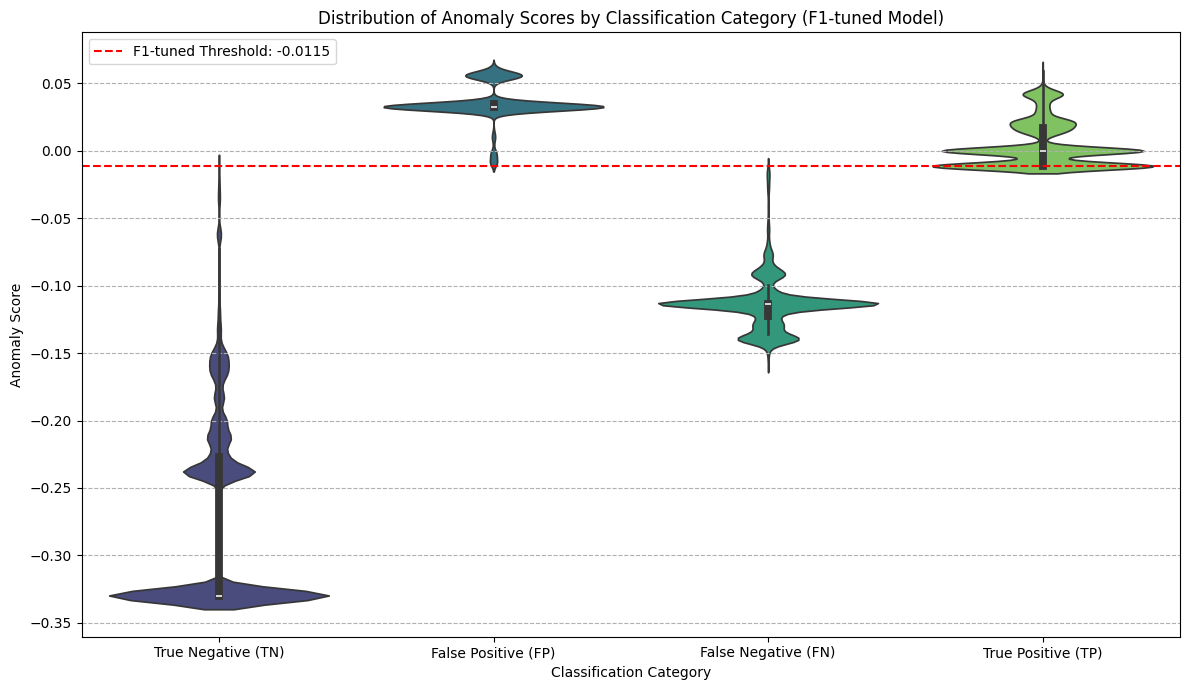

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.violinplot(x='classification_category', y='anomaly_score', data=plot_df, palette='viridis', order=['True Negative (TN)', 'False Positive (FP)', 'False Negative (FN)', 'True Positive (TP)'])
plt.axhline(y=best_t, color='r', linestyle='--', label=f'F1-tuned Threshold: {best_t:.4f}')
plt.title('Distribution of Anomaly Scores by Classification Category (F1-tuned Model)')
plt.xlabel('Classification Category')
plt.ylabel('Anomaly Score')
plt.legend()
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

**Reasoning**:
The previous `seaborn.violinplot` call generated a `FutureWarning` because `palette` was passed without assigning `hue`. To address this, I will explicitly set `hue` to `classification_category` and `legend` to `False` as suggested by the warning.



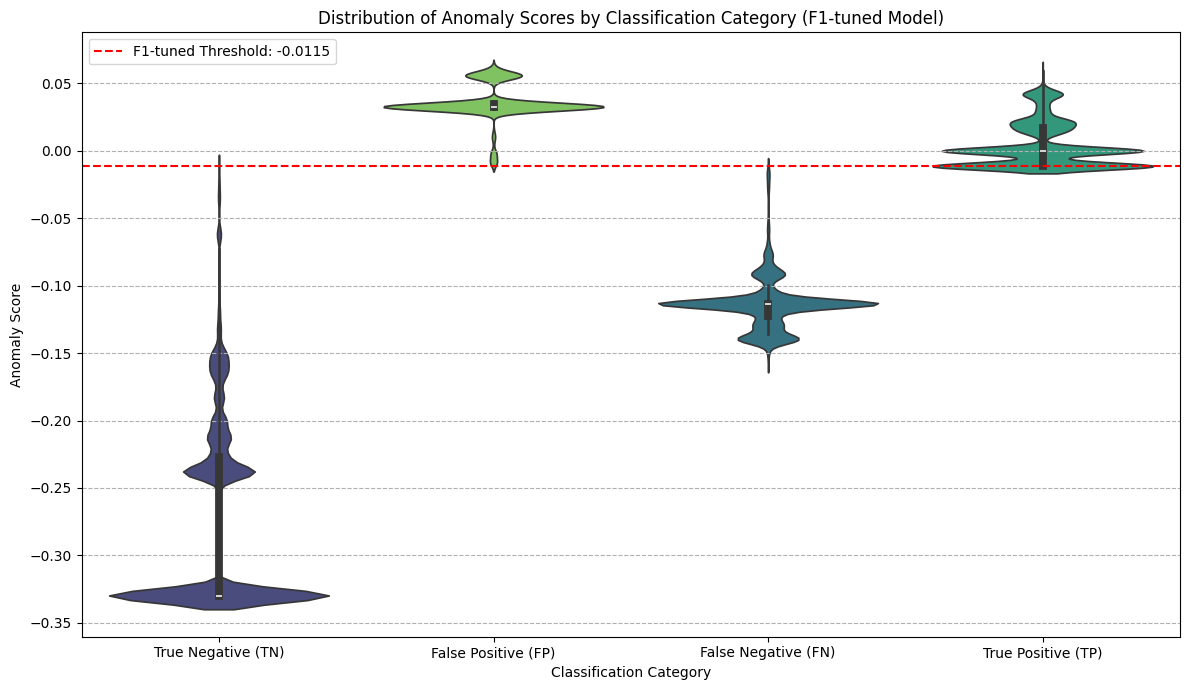

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.violinplot(x='classification_category', y='anomaly_score', data=plot_df, palette='viridis', order=['True Negative (TN)', 'False Positive (FP)', 'False Negative (FN)', 'True Positive (TP)'], hue='classification_category', legend=False)
plt.axhline(y=best_t, color='r', linestyle='--', label=f'F1-tuned Threshold: {best_t:.4f}')
plt.title('Distribution of Anomaly Scores by Classification Category (F1-tuned Model)')
plt.xlabel('Classification Category')
plt.ylabel('Anomaly Score')
plt.legend()
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

### Summary of Insights from Anomaly Score Distributions

From the violin plot visualizing the anomaly score distributions for each classification category, we can draw several insights, particularly regarding False Positives (FP) and False Negatives (FN):

1.  **True Negatives (TN):** The distribution for True Negatives (correctly identified normal points) is heavily concentrated at lower anomaly scores, well below the F1-tuned threshold. This indicates that the model is generally confident in classifying these as normal.

2.  **True Positives (TP):** The distribution for True Positives (correctly identified anomalous points) is concentrated at higher anomaly scores, well above the F1-tuned threshold. This shows that true anomalies generally exhibit distinctively high anomaly scores, allowing the model to classify them correctly.

3.  **False Positives (FP):** False Positives are points that were predicted as anomalies but are actually normal. Their anomaly score distribution largely overlaps with the higher end of the True Negative distribution and lies just above the F1-tuned threshold. This suggests that FPs are normal points that have anomaly scores very close to the decision boundary. They are not as 'normal' as the bulk of TNs, but not truly anomalous either, making them challenging to distinguish. They represent instances where the model was too aggressive in identifying anomalies.

4.  **False Negatives (FN):** False Negatives are points that were predicted as normal but are actually anomalous. Their anomaly score distribution lies *below* the F1-tuned threshold, often overlapping significantly with the True Negative distribution. This indicates that FNs are true anomalies that have anomaly scores closer to normal instances, causing the model to miss them. These are typically the 'hardest' anomalies to detect because their features make them appear similar to normal data points, leading to lower anomaly scores than other true anomalies. They represent instances where the model was too conservative.

**Key Takeaway:** The F1-tuned threshold effectively balances precision and recall by positioning itself in the region where the distributions of normal (TN/FP) and anomalous (FN/TP) points overlap. False Positives tend to be normal instances with unusually high anomaly scores (just above the threshold), while False Negatives are anomalous instances with unusually low anomaly scores (just below the threshold).

### Summary of Insights from Anomaly Score Distributions

From the violin plot visualizing the anomaly score distributions for each classification category, we can draw several insights, particularly regarding False Positives (FP) and False Negatives (FN):

1.  **True Negatives (TN):** The distribution for True Negatives (correctly identified normal points) is heavily concentrated at lower anomaly scores, well below the F1-tuned threshold. This indicates that the model is generally confident in classifying these as normal.

2.  **True Positives (TP):** The distribution for True Positives (correctly identified anomalous points) is concentrated at higher anomaly scores, well above the F1-tuned threshold. This shows that true anomalies generally exhibit distinctively high anomaly scores, allowing the model to classify them correctly.

3.  **False Positives (FP):** False Positives are points that were predicted as anomalies but are actually normal. Their anomaly score distribution largely overlaps with the higher end of the True Negative distribution and lies just above the F1-tuned threshold. This suggests that FPs are normal points that have anomaly scores very close to the decision boundary. They are not as 'normal' as the bulk of TNs, but not truly anomalous either, making them challenging to distinguish. They represent instances where the model was too aggressive in identifying anomalies.

4.  **False Negatives (FN):** False Negatives are points that were predicted as normal but are actually anomalous. Their anomaly score distribution lies *below* the F1-tuned threshold, often overlapping significantly with the True Negative distribution. This indicates that FNs are true anomalies that have anomaly scores closer to normal instances, causing the model to miss them. These are typically the 'hardest' anomalies to detect because their features make them appear similar to normal data points, leading to lower anomaly scores than other true anomalies. They represent instances where the model was too conservative.

**Key Takeaway:** The F1-tuned threshold effectively balances precision and recall by positioning itself in the region where the distributions of normal (TN/FP) and anomalous (FN/TP) points overlap. False Positives tend to be normal instances with unusually high anomaly scores (just above the threshold), while False Negatives are anomalous instances with unusually low anomaly scores (just below the threshold).

## Final Task

### Subtask:
Summarize the insights gained from the visualization of the misclassified points, specifically noting the characteristics of False Positives and False Negatives in terms of their anomaly scores.


## Summary:

### Q&A
The visualization of misclassified points reveals that False Positives (FPs) are normal points with anomaly scores that are unusually high, typically located just above the F1-tuned threshold. Conversely, False Negatives (FNs) are true anomalies that exhibit unusually low anomaly scores, generally falling just below the F1-tuned threshold.

### Data Analysis Key Findings
*   **True Negatives (TN)** are concentrated at lower anomaly scores, well below the F1-tuned threshold, indicating confident classification of normal points.
*   **True Positives (TP)** are concentrated at higher anomaly scores, well above the F1-tuned threshold, demonstrating effective detection of distinct anomalies.
*   **False Positives (FP)** exhibit anomaly scores largely overlapping with the higher end of the True Negative distribution, positioned just above the F1-tuned threshold. These are normal points with borderline high anomaly scores, challenging to distinguish.
*   **False Negatives (FN)** show anomaly scores largely overlapping with the True Negative distribution, positioned just below the F1-tuned threshold. These are true anomalies with borderline low anomaly scores, making them difficult to detect.

### Insights or Next Steps
*   The F1-tuned threshold effectively balances precision and recall by positioning itself in the region where the distributions of normal (TN/FP) and anomalous (FN/TP) points overlap.
*   To further improve model performance, future efforts could focus on techniques to better distinguish between normal instances with high anomaly scores (FPs) and true anomalies with low anomaly scores (FNs), possibly through exploring different feature engineering or more sophisticated anomaly detection algorithms.
